## Objetivo del proyecto

## Predecir la demanda diaria de productos por tienda para optimizar el inventario, evitando quiebres de stock y sobreinventario. Teniendo en cuenta que nuestra variable objetivo es "sales", de la misma manera tendremos niveles de predicción en donde obtendremos 1.Por tienda (store), 2.Por producto (item), 3.Por día (date).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
df = pd.read_csv("/Users/marcelocallao/Desktop/Proyectos GitHub/Sistema de Predicción de Demanda y Optimización de Inventario en Retail/data/raw/retail_sales.csv", parse_dates=["date"])
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


In [5]:
df.shape # cantidad de filas y columnas
df.info() # tipo de datos
df.describe() # descripción estadística

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype         
---  ------    -----         
 0   date      datetime64[ns]
 1   store_id  object        
 2   item_id   object        
 3   sales     int64         
 4   price     float64       
 5   promo     int64         
 6   weekday   int64         
 7   month     int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(2)
memory usage: 278.6+ MB


,date,sales,price,promo,weekday,month
count,4565000,4.565000e+06,4.565000e+06,4.565000e+06,4.565000e+06,4.565000e+06
mean,2021-07-01 11:59:59.999999232,2.926466e+01,5.399323e+01,9.999869e-02,3.001643e+00,6.523549e+00
min,2019-01-01 00:00:00,0.000000e+00,8.020000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,2020-04-01 00:00:00,1.800000e+01,3.197000e+01,0.000000e+00,1.000000e+00,4.000000e+00
50%,2021-07-01 12:00:00,2.700000e+01,5.352000e+01,0.000000e+00,3.000000e+00,7.000000e+00
75%,2022-10-01 00:00:00,3.800000e+01,7.536000e+01,0.000000e+00,5.000000e+00,1.000000e+01
max,2023-12-31 00:00:00,1.390000e+02,9.999000e+01,1.000000e+00,6.000000e+00,1.200000e+01
std,NaN,1.500996e+01,2.578461e+01,2.999983e-01,1.999315e+00,3.448534e+00


In [6]:
df.isnull().sum() # validación calidad de datos (revisar nulos)

date        0
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64

In [7]:
df["date"].min(), df["date"].max() # validar rango de fechas

(Timestamp('2019-01-01 00:00:00'), Timestamp('2023-12-31 00:00:00'))

In [9]:
# Cuantas tiendas y productos existen
df["store_id"].nunique()
df["item_id"].nunique()

50

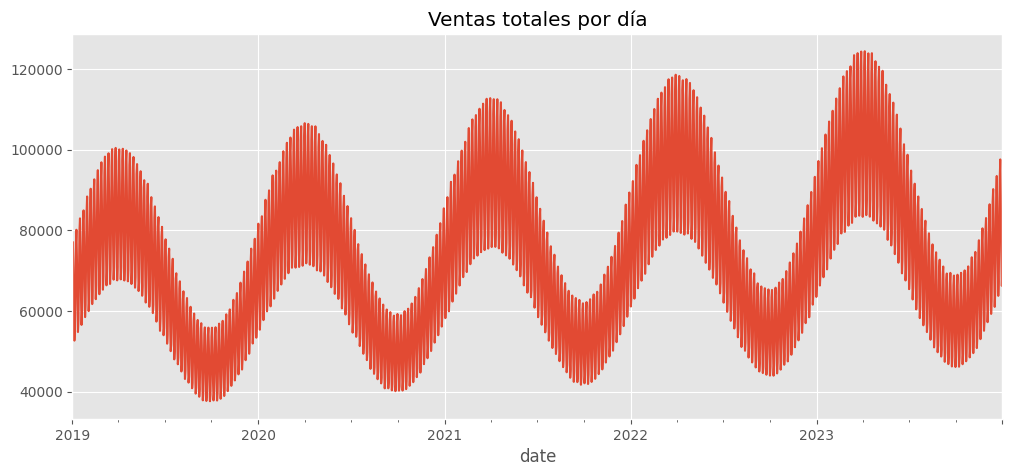

In [10]:
# Ventas totales en el tiempo
df.groupby("date")["sales"].sum().plot(figsize=(12,5))
plt.title("Ventas totales por día")
plt.show()

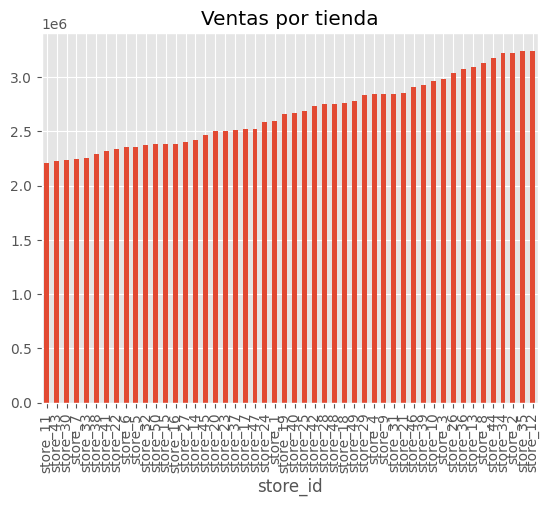

In [12]:
# Ventas por tienda
df.groupby("store_id")["sales"].sum().sort_values().plot(kind="bar")
plt.title("Ventas por tienda")
plt.show()

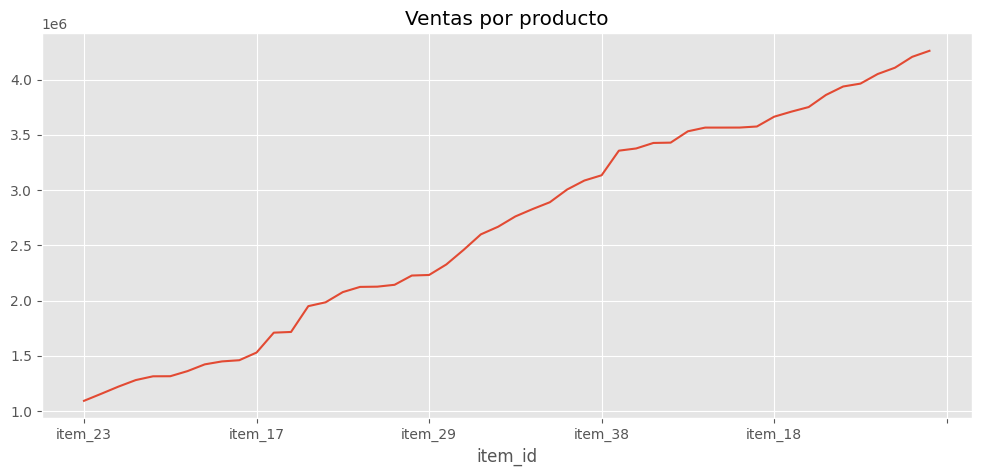

In [13]:
# Ventas por producto
df.groupby("item_id")["sales"].sum().sort_values().plot(figsize=(12,5))
plt.title("Ventas por producto")
plt.show()

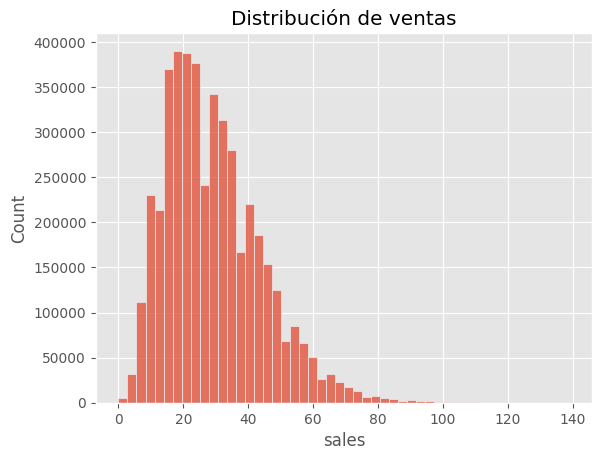

In [14]:
# Distribución de ventas
sns.histplot(df["sales"], bins=50)
plt.title("Distribución de ventas")
plt.show()

## Insights

- Existe estacionalidad en las ventas (picos recurrentes)
- Algunas tiendas venden significativamente más que otras
- La distribución de ventas está sesgada
- Hay alta variabilidad entre productos

## Implicaciones

- Se requieren features de tiempo (mes, día, semana)
- Modelos deben capturar estacionalidad
- Posible segmentación por tienda/producto